#  Автоэнкодеры

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы:
* https://www.eecs.qmul.ac.uk/~sgg/_ECS795P_/papers/WK07-8_PyTorch_Tutorial2.html
* https://www.youtube.com/watch?v=zp8clK9yCro
* https://medium.com/@rekalantar/variational-auto-encoder-vae-pytorch-tutorial-dce2d2fe0f5f
* https://towardsdatascience.com/conditional-variational-autoencoders-with-learnable-conditional-embeddings-e22ee5359a2a
* https://pytorch.org/vision/stable/auto_examples/others/plot_visualization_utils.html#sphx-glr-auto-examples-others-plot-visualization-utils-py

## Задачи для совместного разбора

1\. Обсудите основные шаги в обучении автокодировщиков.

## Задачи для самостоятельного решения

In [1]:
# 🟧 - ошибка/всё плохо
# 🟩 - всё хорошо, обучающая выборка/результаты
# 🟪 - тестовая выборка/результаты
# 🟦 - валидационная выборка/результаты

In [2]:
# ИСПОЛЬЗУЕМЫЕ БИБЛИОТЕКИ
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import datasets

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')

def load_state_dict_safe(path, map_location=None):
    """Безопасная загрузка tensor-only state_dict для разных версий PyTorch."""
    if not os.path.exists(path):
        raise FileNotFoundError(f'Файл {path} не найден. Сначала выполните обучение в предыдущем задании.')
    if map_location is None:
        map_location = device
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:  # PyTorch < 2.0/старые сигнатуры
        return torch.load(path, map_location=map_location)


Устройство: cuda


<p class="task" id="1"></p>

1\. Загрузите набор данных MNIST из пакета `torchvision` (данный набор уже разбит на обучающее и тестовое множество).

Создайте и обучите модель автокодировщика, используя только полносвязные слои и функции активации.

Кодировщик - это функция вида
$z = f_\theta(x)$
,где $\theta$ - это параметры кодировщика.

Декодировщик - это функция вида
$\hat{x} = g_\phi(z)$
,где $\phi$ - это параметры декодировщика.

В нашем случае оба компонента представляют собой нейронные сети. Скрытое представление, полученное после части-кодировщика, должно иметь размерность 2. Последним слоем части-декодеровщика сделайте сигмоиду.

В качестве функции потерь используйте `MSELoss` между исходным и восстановленным изображением $MSE(x, \hat{x})$.

Обратите внимание, что во время обучения метки классов не используются.


- [ ] Проверено на семинаре

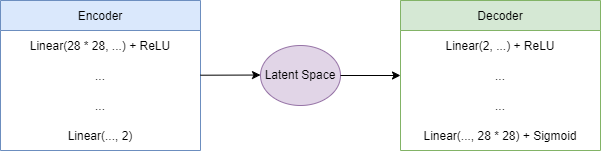

In [3]:
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
print(f'Train: {len(train_dataset)}, Test: {len(test_dataset)}')


Train: 60000, Test: 10000


In [4]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=(128, 64, 32), latent_dim=2):
        super().__init__()
        encoder_layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            encoder_layers += [nn.Linear(prev_dim, hidden_dim), nn.ReLU()]
            prev_dim = hidden_dim
        encoder_layers.append(nn.Linear(prev_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        decoder_layers = []
        prev_dim = latent_dim
        for hidden_dim in reversed(hidden_dims):
            decoder_layers += [nn.Linear(prev_dim, hidden_dim), nn.ReLU()]
            prev_dim = hidden_dim
        decoder_layers += [nn.Linear(prev_dim, input_dim), nn.Sigmoid()]
        self.decoder = nn.Sequential(*decoder_layers)
        self.latent_dim = latent_dim

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


In [5]:
model = Autoencoder(latent_dim=2).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
model


Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=784, bias=True)
    (7): Sigmoid()
  )
)

In [6]:
num_epochs = 10
train_losses = []
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for data, _ in train_loader:
        data = data.view(data.size(0), -1).to(device)
        reconstructed, _ = model(data)
        loss = criterion(reconstructed, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1:02d}/{num_epochs}], MSE: {epoch_loss:.5f}')

torch.save(model.state_dict(), 'autoencoder_model.pth')
print('Модель сохранена: autoencoder_model.pth')


Epoch [01/10], MSE: 0.06757
Epoch [02/10], MSE: 0.05066
Epoch [03/10], MSE: 0.04730
Epoch [04/10], MSE: 0.04473
Epoch [05/10], MSE: 0.04327
Epoch [06/10], MSE: 0.04201
Epoch [07/10], MSE: 0.04124
Epoch [08/10], MSE: 0.04059
Epoch [09/10], MSE: 0.04006
Epoch [10/10], MSE: 0.03967
Модель сохранена: autoencoder_model.pth


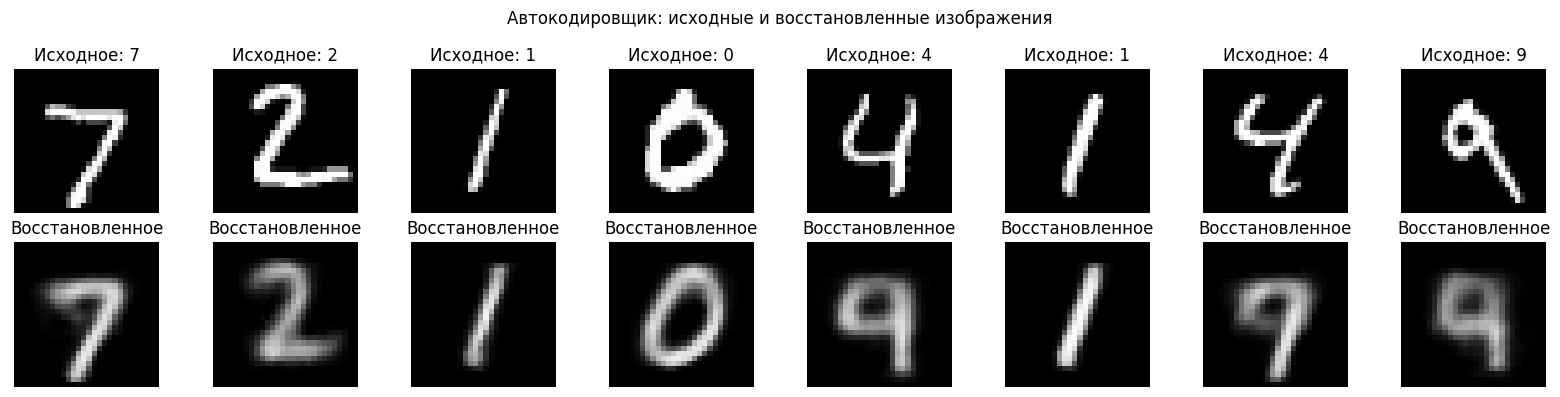

In [7]:
model.eval()
with torch.no_grad():
    images, labels = next(iter(test_loader))
    images_flat = images.view(images.size(0), -1).to(device)
    reconstructed, latent = model(images_flat)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(images[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'Исходное: {labels[i].item()}')
    axes[1, i].imshow(reconstructed[i].detach().cpu().view(28, 28), cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title('Восстановленное')
    axes[0, i].axis('off'); axes[1, i].axis('off')
plt.suptitle('Автокодировщик: исходные и восстановленные изображения')
plt.tight_layout(); plt.show()


Размерность latent space: (10000, 2)


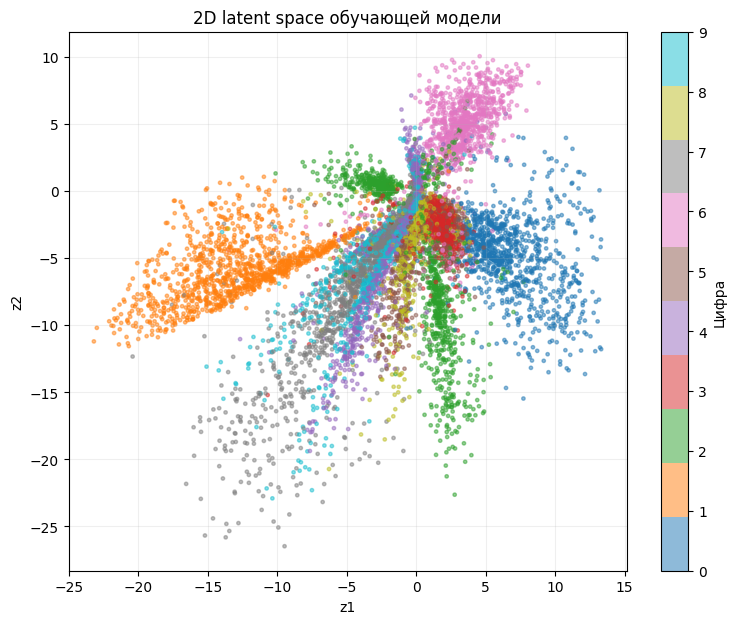

In [8]:
# Проверка, что скрытое представление действительно двумерное
model.eval()
all_latent, all_labels = [], []
with torch.no_grad():
    for data, labels in test_loader:
        z = model.encoder(data.view(data.size(0), -1).to(device))
        all_latent.append(z.cpu().numpy())
        all_labels.append(labels.numpy())
all_latent = np.concatenate(all_latent)
all_labels = np.concatenate(all_labels)
print('Размерность latent space:', all_latent.shape)

plt.figure(figsize=(9, 7))
sc = plt.scatter(all_latent[:, 0], all_latent[:, 1], c=all_labels, cmap='tab10', s=6, alpha=.5)
plt.colorbar(sc, ticks=range(10), label='Цифра')
plt.xlabel('z1'); plt.ylabel('z2'); plt.title('2D latent space обучающей модели')
plt.grid(alpha=.2); plt.show()


In [9]:
# Примеры координат двумерного скрытого пространства
for cls in range(10):
    mask = all_labels == cls
    mean_z = all_latent[mask].mean(axis=0)
    print(f'Класс {cls}: mean z = [{mean_z[0]:.3f}, {mean_z[1]:.3f}]')


Класс 0: mean z = [6.760, -4.806]
Класс 1: mean z = [-12.666, -5.689]
Класс 2: mean z = [-0.003, -4.938]
Класс 3: mean z = [1.363, -2.339]
Класс 4: mean z = [-1.895, -4.278]
Класс 5: mean z = [0.648, -3.624]
Класс 6: mean z = [3.215, 4.308]
Класс 7: mean z = [-5.231, -8.033]
Класс 8: mean z = [0.093, -3.323]
Класс 9: mean z = [-2.581, -4.556]


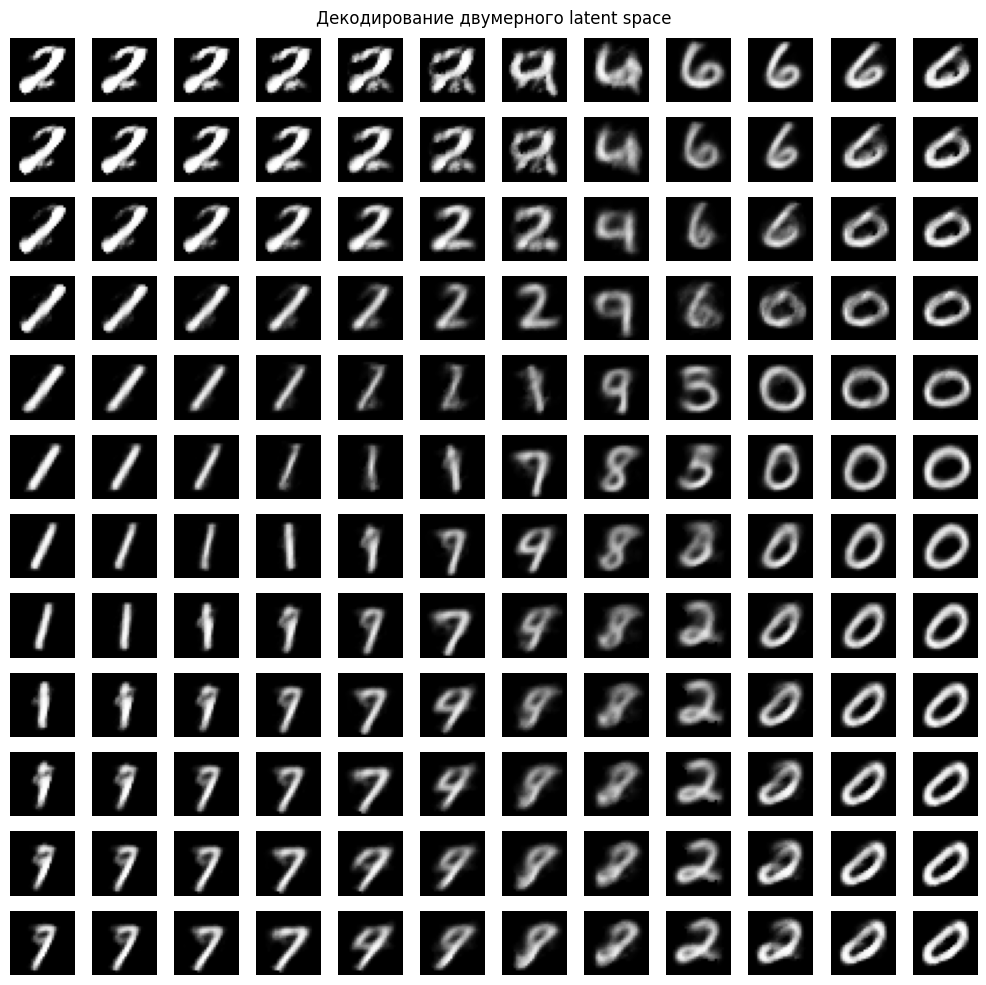

In [10]:
# Декодирование регулярной сетки точек двумерного latent space
grid_size = 12
x_vals = np.linspace(np.percentile(all_latent[:, 0], 2), np.percentile(all_latent[:, 0], 98), grid_size)
y_vals = np.linspace(np.percentile(all_latent[:, 1], 2), np.percentile(all_latent[:, 1], 98), grid_size)
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
model.eval()
with torch.no_grad():
    for iy, y in enumerate(y_vals[::-1]):
        for ix, x in enumerate(x_vals):
            z = torch.tensor([[x, y]], dtype=torch.float32, device=device)
            img = model.decoder(z).cpu().view(28, 28)
            axes[iy, ix].imshow(img, cmap='gray', vmin=0, vmax=1)
            axes[iy, ix].axis('off')
plt.suptitle('Декодирование двумерного latent space')
plt.tight_layout(); plt.show()


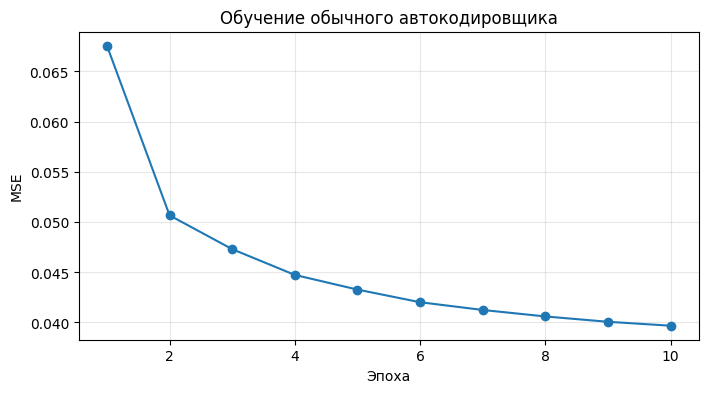

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.xlabel('Эпоха'); plt.ylabel('MSE'); plt.title('Обучение обычного автокодировщика')
plt.grid(alpha=.3); plt.show()


<p class="task" id="2"></p>

2\. Получите один батч из тестового множества. Используя модель, обученную в предыдущем задании, получите скрытые представления для всех изображений из этого батча и визуализируйте на плоскости (они должны иметь размерность 2!). Раскрасьте точки в цвета, соответствующие меткам класса изображений (цифрам).

Возьмите одно изображение из тестового множества и пропустите его через обученный автокодировщик. Визуализируйте рядом (по горизонтали) два изображения: исходное и после восстановления автокодировщиком.


- [ ] Проверено на семинаре

In [12]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=(128, 64, 32), latent_dim=2):
        super().__init__()
        encoder_layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            encoder_layers += [nn.Linear(prev_dim, hidden_dim), nn.ReLU()]
            prev_dim = hidden_dim
        encoder_layers.append(nn.Linear(prev_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        decoder_layers = []
        prev_dim = latent_dim
        for hidden_dim in reversed(hidden_dims):
            decoder_layers += [nn.Linear(prev_dim, hidden_dim), nn.ReLU()]
            prev_dim = hidden_dim
        decoder_layers += [nn.Linear(prev_dim, input_dim), nn.Sigmoid()]
        self.decoder = nn.Sequential(*decoder_layers)
        self.latent_dim = latent_dim

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


In [13]:
model = Autoencoder(latent_dim=2).to(device)


In [14]:
model_path = 'autoencoder_model.pth'
model.load_state_dict(load_state_dict_safe(model_path, map_location=device))
model.eval()
print('Модель из задания 1 загружена; latent_dim = 2')


Модель из задания 1 загружена; latent_dim = 2


In [15]:
# Тестовый loader; shuffle=False для воспроизводимости
transform = transforms.ToTensor()
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [16]:
images, labels = next(iter(test_loader))
print(f'Размер одного тестового батча: {tuple(images.shape)}')
print('Первые 10 меток:', labels[:10].tolist())


Размер одного тестового батча: (64, 1, 28, 28)
Первые 10 меток: [7, 2, 1, 0, 4, 1, 4, 9, 5, 9]


In [17]:
with torch.no_grad():
    images_flat = images.view(images.size(0), -1).to(device)
    reconstructed_images, latent_tensor = model(images_flat)
latent_vectors = latent_tensor.cpu().numpy()
labels_np = labels.numpy()
reconstructed_images = reconstructed_images.cpu()
print('Размер скрытых представлений:', latent_vectors.shape)
assert latent_vectors.shape[1] == 2, 'По условию latent space должен иметь размерность 2'


Размер скрытых представлений: (64, 2)


In [18]:
test_mse = F.mse_loss(reconstructed_images, images_flat.cpu()).item()
print(f'MSE на выбранном батче: {test_mse:.5f}')


MSE на выбранном батче: 0.03795


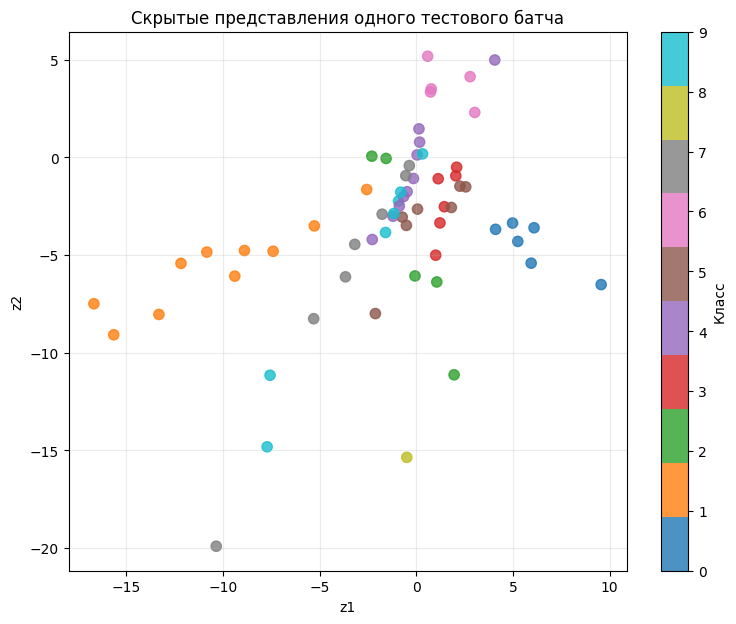

In [19]:
plt.figure(figsize=(9, 7))
sc = plt.scatter(latent_vectors[:, 0], latent_vectors[:, 1], c=labels_np, cmap='tab10', s=55, alpha=.8)
plt.colorbar(sc, ticks=range(10), label='Класс')
plt.xlabel('z1'); plt.ylabel('z2')
plt.title('Скрытые представления одного тестового батча')
plt.grid(alpha=.25); plt.show()


In [20]:
# Одно изображение из тестового батча
idx = 0
single_image = images[idx:idx+1]
single_label = labels[idx].item()
with torch.no_grad():
    single_flat = single_image.view(1, -1).to(device)
    reconstructed_single, latent_single = model(single_flat)
original_img = single_image[0, 0].numpy()
reconstructed_img = reconstructed_single.cpu().view(28, 28).numpy()
latent_vec = latent_single.cpu().numpy()[0]
print(f'Цифра: {single_label}, latent=[{latent_vec[0]:.3f}, {latent_vec[1]:.3f}]')


Цифра: 7, latent=[-5.310, -8.262]


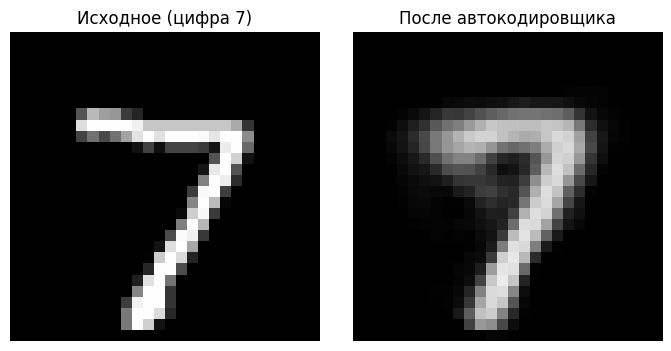

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(original_img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'Исходное (цифра {single_label})')
axes[1].imshow(reconstructed_img, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('После автокодировщика')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


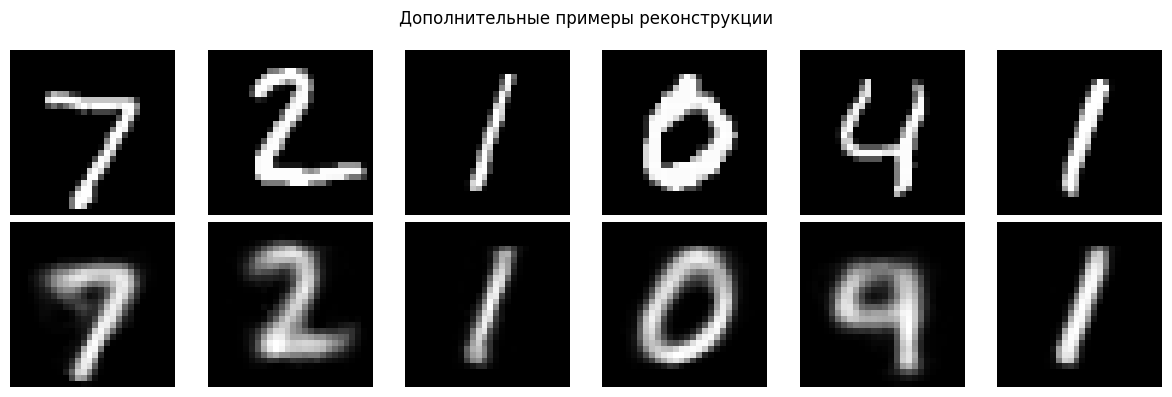

In [22]:
# Несколько пар исходное/восстановленное
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
with torch.no_grad():
    recon_batch, _ = model(images[:6].view(6, -1).to(device))
for i in range(6):
    axes[0, i].imshow(images[i, 0], cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(recon_batch[i].cpu().view(28, 28), cmap='gray'); axes[1, i].axis('off')
plt.suptitle('Дополнительные примеры реконструкции')
plt.tight_layout(); plt.show()


<p class="task" id="3"></p>

3\. Напишите функцию для генерации изображения на основе случайного шума. Функция должна генерировать случайный шум из стандартного нормального распределения и пропускать его через часть-декодировщик. Сгенерируйте несколько изображений и визуализируйте в виде сетки из картинок.

- [ ] Проверено на семинаре

In [23]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=(128, 64, 32), latent_dim=2):
        super().__init__()
        encoder_layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            encoder_layers += [nn.Linear(prev_dim, hidden_dim), nn.ReLU()]
            prev_dim = hidden_dim
        encoder_layers.append(nn.Linear(prev_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        decoder_layers = []
        prev_dim = latent_dim
        for hidden_dim in reversed(hidden_dims):
            decoder_layers += [nn.Linear(prev_dim, hidden_dim), nn.ReLU()]
            prev_dim = hidden_dim
        decoder_layers += [nn.Linear(prev_dim, input_dim), nn.Sigmoid()]
        self.decoder = nn.Sequential(*decoder_layers)
        self.latent_dim = latent_dim

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


In [24]:
model = Autoencoder(latent_dim=2).to(device)
model.load_state_dict(load_state_dict_safe('autoencoder_model.pth', map_location=device))
model.eval()
print('Модель из задания 1 загружена')


Модель из задания 1 загружена


In [25]:
assert model.latent_dim == 2


In [26]:
model.eval()


Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=784, bias=True)
    (7): Sigmoid()
  )
)

In [27]:
def generate_images_from_random_noise(model, num_images=16):
    """Генерация z~N(0,I) и декодирование в изображения."""
    model.eval()
    model_device = next(model.parameters()).device
    with torch.no_grad():
        noise = torch.randn(num_images, model.latent_dim, device=model_device)
        generated = model.decoder(noise)
    return generated.cpu(), noise.cpu()


In [28]:
def visualize_generated_images_grid(generated_images, noise_vectors=None, nrows=4, ncols=4):
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 10))
    axes = np.asarray(axes).reshape(nrows, ncols)
    for idx, ax in enumerate(axes.flat):
        if idx < len(generated_images):
            ax.imshow(generated_images[idx].view(28, 28), cmap='gray', vmin=0, vmax=1)
            if noise_vectors is not None:
                ax.set_title(f'z=({noise_vectors[idx,0]:.2f}, {noise_vectors[idx,1]:.2f})', fontsize=8)
        ax.axis('off')
    plt.suptitle('Генерация из случайного шума z ~ N(0, I)')
    plt.tight_layout(); plt.show()


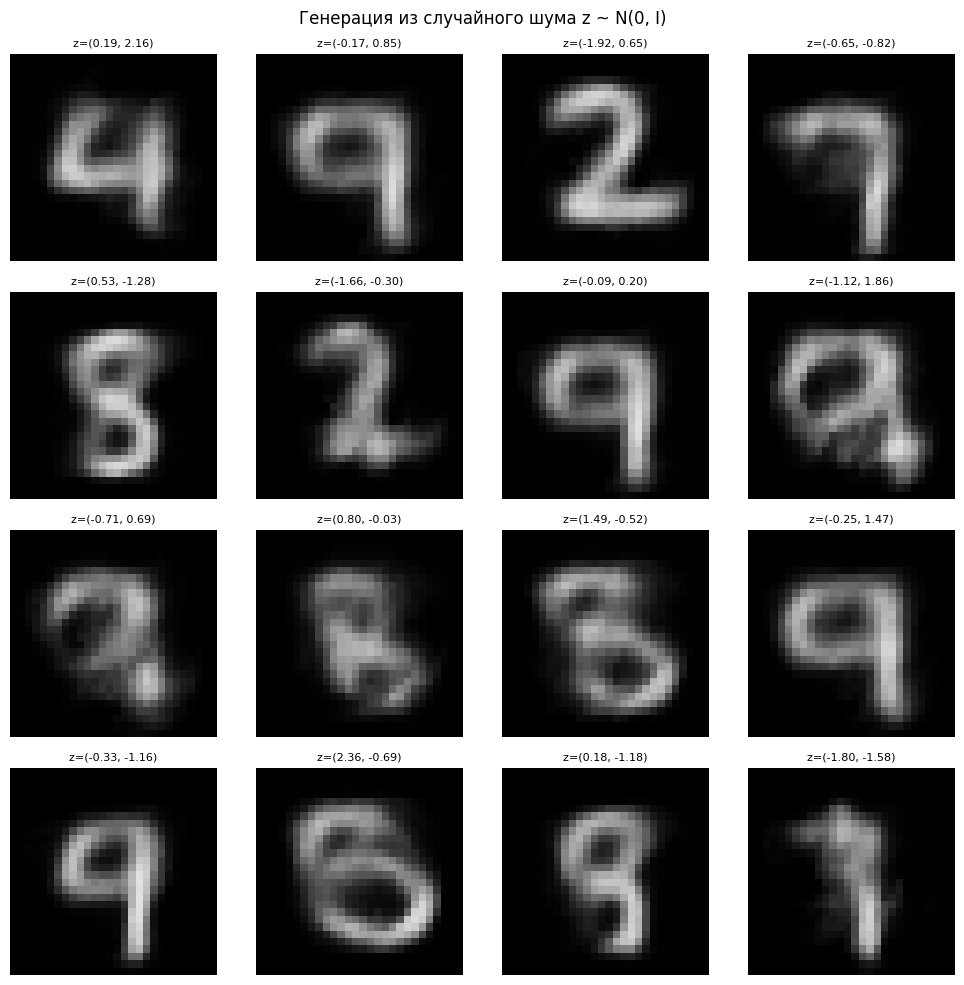

In [29]:
generated_images, noise_vectors = generate_images_from_random_noise(model, num_images=16)
visualize_generated_images_grid(generated_images, noise_vectors, 4, 4)


In [30]:
def generate_from_specific_latent_vectors(model, latent_vectors):
    model_device = next(model.parameters()).device
    z = torch.as_tensor(latent_vectors, dtype=torch.float32, device=model_device)
    with torch.no_grad():
        return model.decoder(z).cpu()


In [31]:
def demonstrate_latent_space_interpolation(model, num_steps=10):
    point_a = torch.randn(2)
    point_b = torch.randn(2)
    alphas = torch.linspace(0, 1, num_steps)
    points = torch.stack([(1-a)*point_a + a*point_b for a in alphas])
    imgs = generate_from_specific_latent_vectors(model, points)
    fig, axes = plt.subplots(1, num_steps, figsize=(1.7*num_steps, 2))
    for i, ax in enumerate(np.atleast_1d(axes)):
        ax.imshow(imgs[i].view(28,28), cmap='gray'); ax.axis('off'); ax.set_title(f'a={alphas[i]:.1f}')
    plt.suptitle('Интерполяция в latent space'); plt.tight_layout(); plt.show()
    return points, imgs


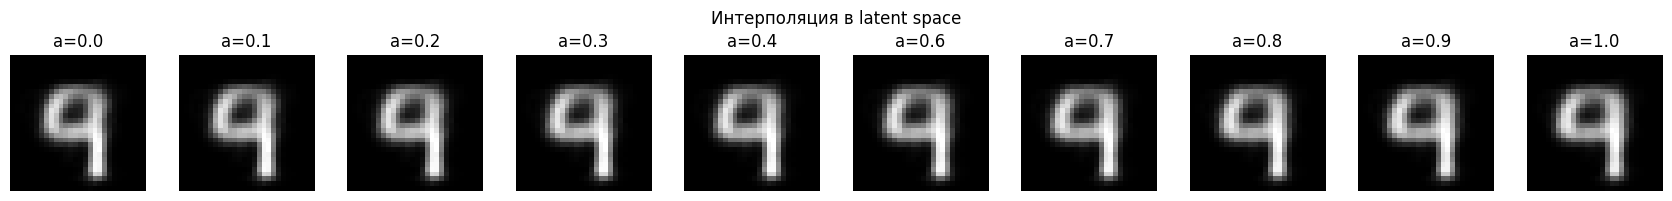

(tensor([[ 0.0716, -0.6090],
         [ 0.0655, -0.5660],
         [ 0.0595, -0.5230],
         [ 0.0535, -0.4799],
         [ 0.0475, -0.4369],
         [ 0.0415, -0.3939],
         [ 0.0355, -0.3508],
         [ 0.0295, -0.3078],
         [ 0.0235, -0.2648],
         [ 0.0175, -0.2217]]),
 tensor([[0.0003, 0.0005, 0.0004,  ..., 0.0004, 0.0005, 0.0005],
         [0.0003, 0.0005, 0.0004,  ..., 0.0003, 0.0005, 0.0004],
         [0.0003, 0.0005, 0.0004,  ..., 0.0003, 0.0005, 0.0004],
         ...,
         [0.0002, 0.0003, 0.0003,  ..., 0.0003, 0.0004, 0.0003],
         [0.0002, 0.0003, 0.0003,  ..., 0.0003, 0.0003, 0.0003],
         [0.0002, 0.0003, 0.0003,  ..., 0.0003, 0.0003, 0.0003]]))

In [32]:
demonstrate_latent_space_interpolation(model, num_steps=10)


In [33]:
def generate_with_different_noise_levels(model, num_images=4, noise_levels=(0.5, 1.0, 1.5, 2.0)):
    fig, axes = plt.subplots(len(noise_levels), num_images, figsize=(2*num_images, 2*len(noise_levels)))
    axes = np.asarray(axes).reshape(len(noise_levels), num_images)
    model_device = next(model.parameters()).device
    with torch.no_grad():
        for r, sigma in enumerate(noise_levels):
            z = torch.randn(num_images, model.latent_dim, device=model_device) * sigma
            imgs = model.decoder(z).cpu()
            for c in range(num_images):
                axes[r,c].imshow(imgs[c].view(28,28), cmap='gray'); axes[r,c].axis('off')
                if c == 0: axes[r,c].set_title(f'sigma={sigma}')
    plt.suptitle('Влияние масштаба случайного шума'); plt.tight_layout(); plt.show()


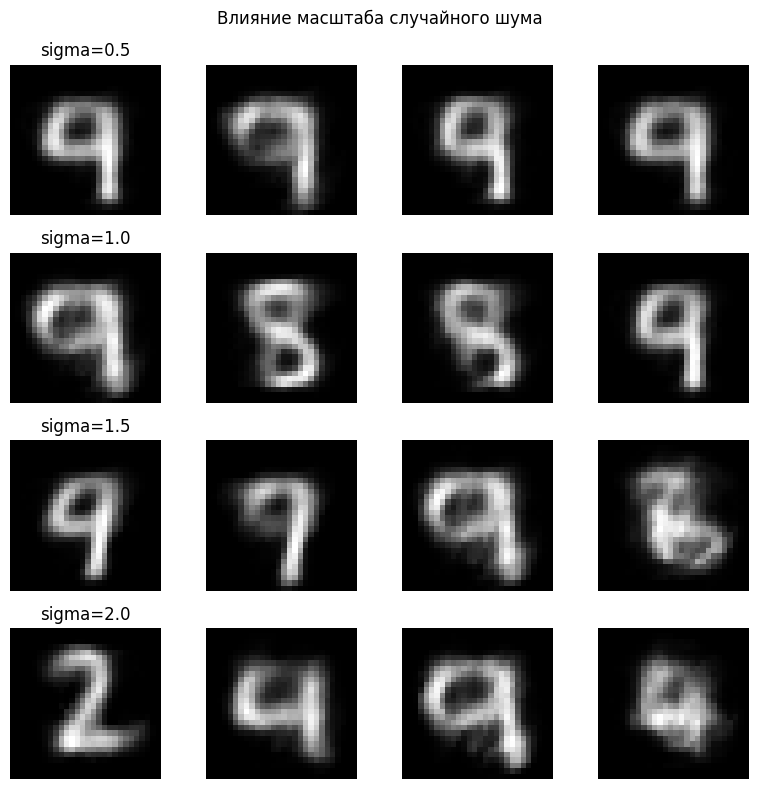

In [34]:
generate_with_different_noise_levels(model, num_images=4, noise_levels=(0.5, 1.0, 1.5, 2.0))


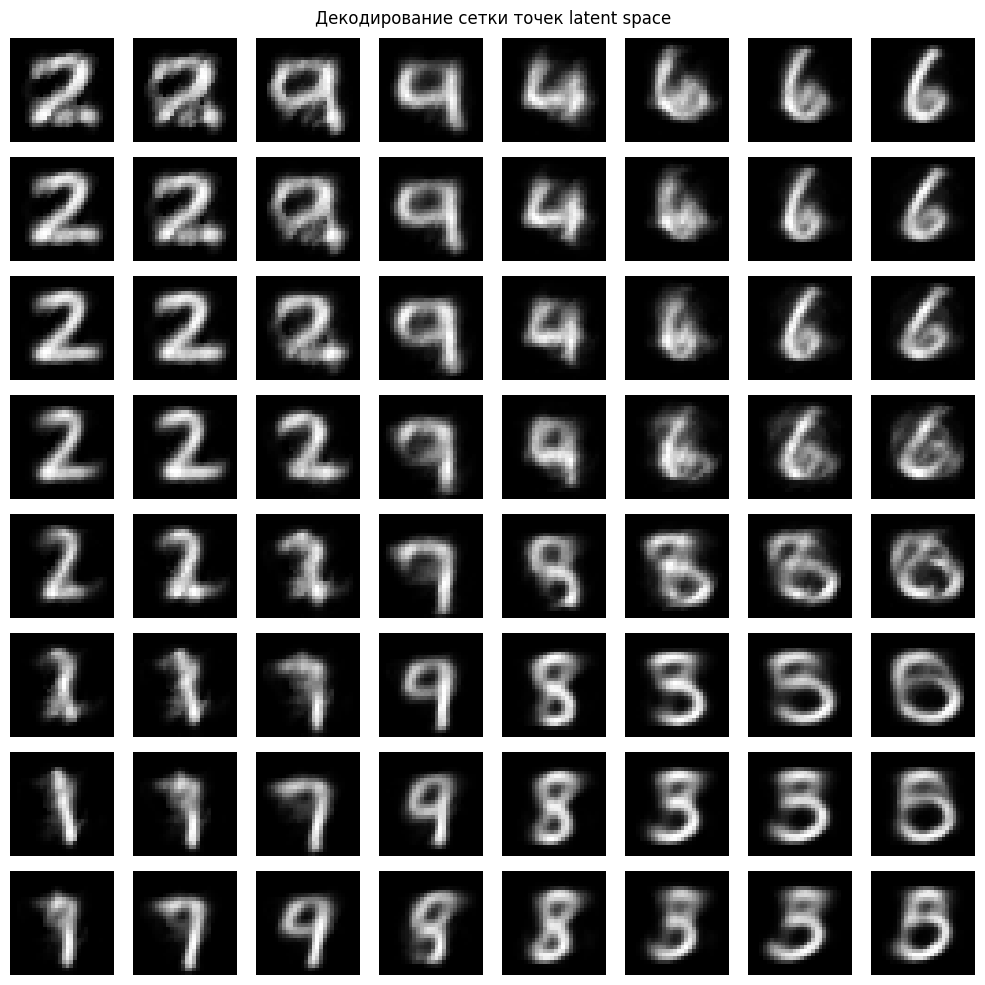

In [35]:
# Сетка декодированных точек latent space
grid_size = 8
x = np.linspace(-3, 3, grid_size); y = np.linspace(-3, 3, grid_size)
points = np.array([[xi, yi] for yi in y[::-1] for xi in x], dtype=np.float32)
imgs = generate_from_specific_latent_vectors(model, points)
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10,10))
for idx, ax in enumerate(axes.flat):
    ax.imshow(imgs[idx].view(28,28), cmap='gray'); ax.axis('off')
plt.suptitle('Декодирование сетки точек latent space'); plt.tight_layout(); plt.show()


<p class="task" id="4"></p>

4\. Создайте и обучите модель условного автокодировщика, используя только полносвязные слои и функции активации.

Отличие от предыдущего варианта заключается в том, что теперь функции кодировщика и декодировщика принимают на вход также метку класса:
$$z = f_\theta(x, c)$$
$$\hat{x} = g_\phi(z, c)$$

Таким образом, теперь во теперь время обучения метки классов используются. Задействуйте их следующим образом: представьте метки классов в виде one-hot кодировки и объедините с пикселями изображения (для этого адаптируйте размерность слоев).

Скрытое представление, полученное после части-кодировщика, должно иметь размерность 2. Последним слоем части-декодеровщика сделайте сигмоиду. В качестве функции потерь используйте `MSELoss` между исходным и восстановленным изображением $MSE(x, \hat{x})$.


- [ ] Проверено на семинаре

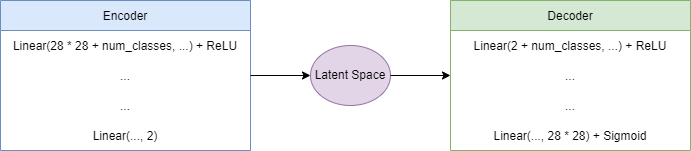

In [36]:
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


In [37]:
class ConditionalAutoencoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=(256, 128, 64), latent_dim=2, num_classes=10):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        enc = []
        prev = input_dim + num_classes
        for h in hidden_dims:
            enc += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        enc.append(nn.Linear(prev, latent_dim))
        self.encoder = nn.Sequential(*enc)

        dec = []
        prev = latent_dim + num_classes
        for h in reversed(hidden_dims):
            dec += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        dec += [nn.Linear(prev, input_dim), nn.Sigmoid()]
        self.decoder = nn.Sequential(*dec)

    def one_hot(self, labels, dtype=torch.float32):
        return F.one_hot(labels.long(), num_classes=self.num_classes).to(dtype=dtype)

    def encode(self, x, labels):
        condition = self.one_hot(labels, x.dtype).to(x.device)
        return self.encoder(torch.cat([x, condition], dim=1))

    def decode_condition(self, z, condition):
        condition = condition.to(device=z.device, dtype=z.dtype)
        return self.decoder(torch.cat([z, condition], dim=1))

    def decode(self, z, labels):
        condition = self.one_hot(labels, z.dtype).to(z.device)
        return self.decode_condition(z, condition)

    def forward(self, x, labels):
        z = self.encode(x, labels)
        return self.decode(z, labels), z


In [38]:
num_classes = 10
model = ConditionalAutoencoder(num_classes=num_classes, latent_dim=2).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
# Проверка: метка представляется именно one-hot, а не обучаемым embedding
print('one-hot(3) =', model.one_hot(torch.tensor([3])).cpu().numpy())


one-hot(3) = [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


In [39]:
num_epochs = 15
train_losses = []
for epoch in range(num_epochs):
    model.train(); running_loss = 0.0
    for data, labels in train_loader:
        data = data.view(data.size(0), -1).to(device)
        labels = labels.to(device)
        reconstructed, _ = model(data, labels)
        loss = criterion(reconstructed, data)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1:02d}/{num_epochs}], MSE: {epoch_loss:.5f}')


Epoch [01/15], MSE: 0.05794
Epoch [02/15], MSE: 0.03867
Epoch [03/15], MSE: 0.03602
Epoch [04/15], MSE: 0.03490
Epoch [05/15], MSE: 0.03416
Epoch [06/15], MSE: 0.03363
Epoch [07/15], MSE: 0.03326
Epoch [08/15], MSE: 0.03296
Epoch [09/15], MSE: 0.03267
Epoch [10/15], MSE: 0.03249
Epoch [11/15], MSE: 0.03230
Epoch [12/15], MSE: 0.03211
Epoch [13/15], MSE: 0.03197
Epoch [14/15], MSE: 0.03182
Epoch [15/15], MSE: 0.03169


In [40]:
torch.save(model.state_dict(), 'conditional_autoencoder_model.pth')
print('Модель сохранена: conditional_autoencoder_model.pth')


Модель сохранена: conditional_autoencoder_model.pth


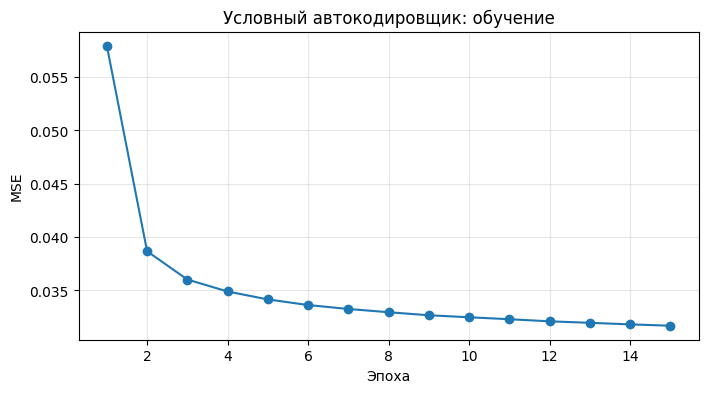

In [41]:
plt.figure(figsize=(8,4)); plt.plot(range(1,num_epochs+1), train_losses, marker='o')
plt.xlabel('Эпоха'); plt.ylabel('MSE'); plt.title('Условный автокодировщик: обучение'); plt.grid(alpha=.3); plt.show()


In [42]:
def test_conditional_model():
    model.eval(); total = 0.0
    with torch.no_grad():
        for data, labels in test_loader:
            data = data.view(data.size(0), -1).to(device); labels = labels.to(device)
            recon, _ = model(data, labels)
            total += criterion(recon, data).item()
    value = total / len(test_loader)
    print(f'Test MSE: {value:.5f}')
    return value
conditional_test_mse = test_conditional_model()


Test MSE: 0.03208


In [43]:
def visualize_latent_space(latent_vectors, labels, title='Latent space условного автокодировщика'):
    plt.figure(figsize=(9,7))
    sc = plt.scatter(latent_vectors[:,0], latent_vectors[:,1], c=labels, cmap='tab10', s=10, alpha=.6)
    plt.colorbar(sc, ticks=range(10), label='Класс'); plt.xlabel('z1'); plt.ylabel('z2'); plt.title(title)
    plt.grid(alpha=.2); plt.show()


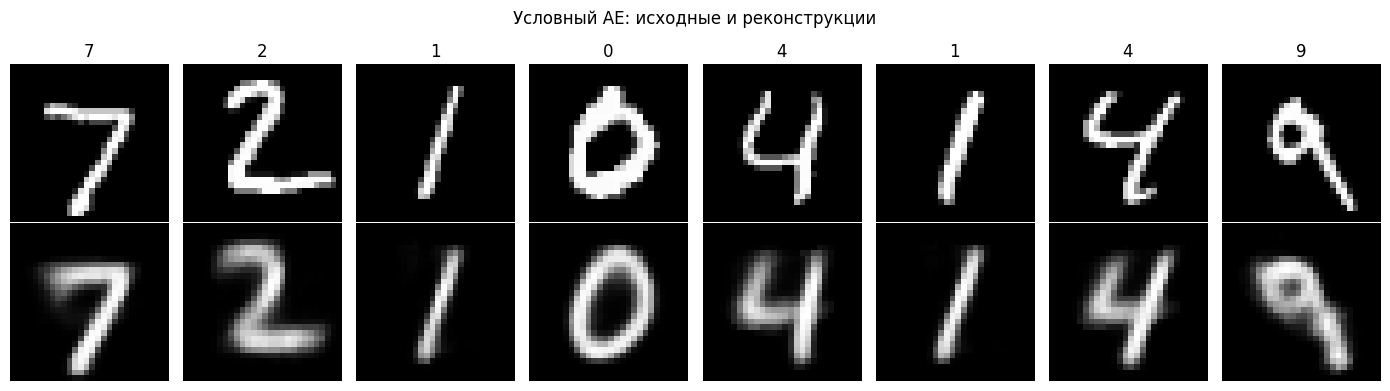

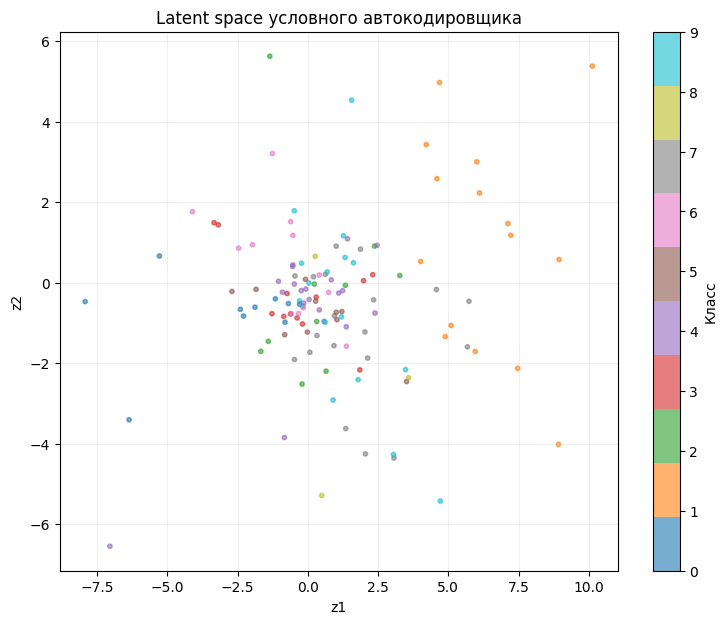

In [44]:
model.eval(); images, labels = next(iter(test_loader))
with torch.no_grad():
    flat = images.view(images.size(0), -1).to(device)
    recon, z = model(flat, labels.to(device))
fig, axes = plt.subplots(2, 8, figsize=(14,4))
for i in range(8):
    axes[0,i].imshow(images[i,0], cmap='gray'); axes[1,i].imshow(recon[i].cpu().view(28,28), cmap='gray')
    axes[0,i].axis('off'); axes[1,i].axis('off'); axes[0,i].set_title(str(labels[i].item()))
plt.suptitle('Условный AE: исходные и реконструкции'); plt.tight_layout(); plt.show()
visualize_latent_space(z.cpu().numpy(), labels.numpy())


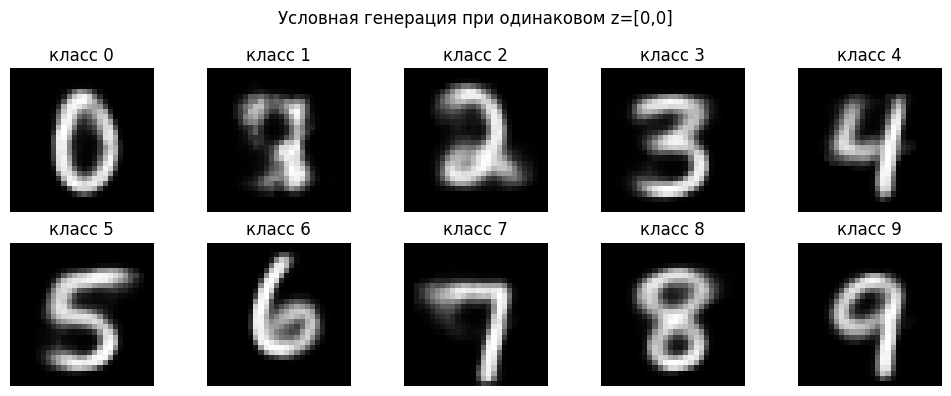

In [45]:
# Один и тот же z + разные one-hot классы: влияние условия
a = torch.arange(10, device=device)
z0 = torch.zeros(10, 2, device=device)
with torch.no_grad(): imgs = model.decode(z0, a).cpu()
fig, axes = plt.subplots(2,5,figsize=(10,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].view(28,28), cmap='gray'); ax.axis('off'); ax.set_title(f'класс {i}')
plt.suptitle('Условная генерация при одинаковом z=[0,0]'); plt.tight_layout(); plt.show()


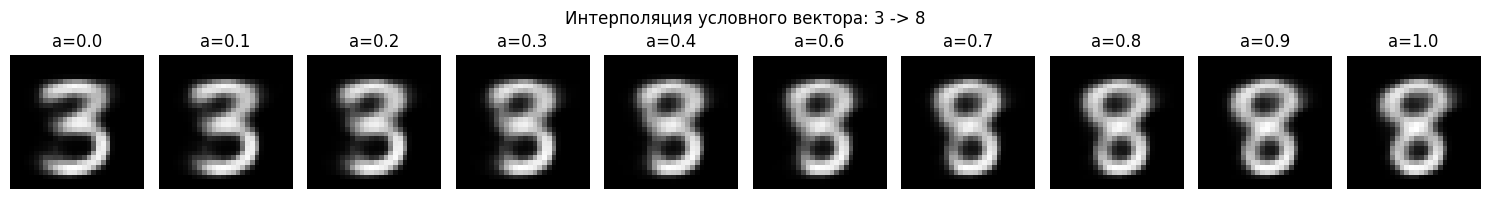

In [46]:
# Плавная интерполяция между условиями класса 3 и 8
class_a, class_b = 3, 8
one_a = F.one_hot(torch.tensor([class_a], device=device), 10).float()
one_b = F.one_hot(torch.tensor([class_b], device=device), 10).float()
z = torch.zeros(1,2,device=device)
alphas = torch.linspace(0,1,10,device=device)
with torch.no_grad():
    imgs = [model.decode_condition(z, (1-a)*one_a + a*one_b).cpu() for a in alphas]
fig, axes = plt.subplots(1,10,figsize=(15,2))
for i, ax in enumerate(axes):
    ax.imshow(imgs[i].view(28,28), cmap='gray'); ax.axis('off'); ax.set_title(f'a={alphas[i].item():.1f}')
plt.suptitle('Интерполяция условного вектора: 3 -> 8'); plt.tight_layout(); plt.show()


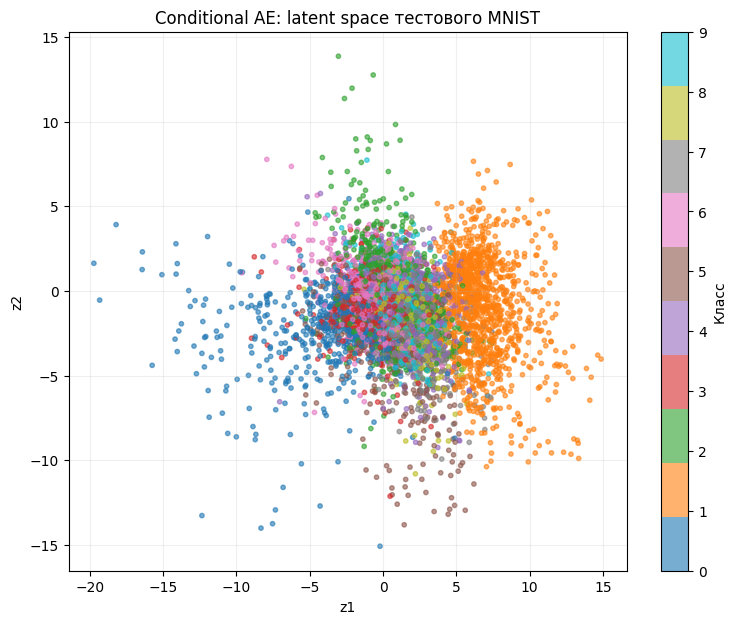

In [47]:
# Latent space на всём тестовом наборе
model.eval(); zs=[]; ys=[]
with torch.no_grad():
    for data, labels in test_loader:
        z = model.encode(data.view(data.size(0),-1).to(device), labels.to(device))
        zs.append(z.cpu().numpy()); ys.append(labels.numpy())
zs=np.concatenate(zs); ys=np.concatenate(ys)
visualize_latent_space(zs, ys, 'Conditional AE: latent space тестового MNIST')


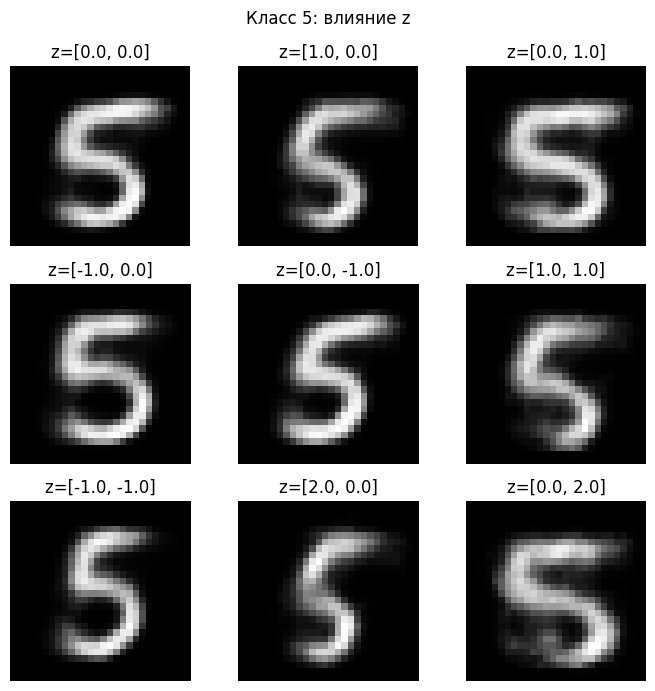

In [48]:
# Разные latent-векторы для фиксированного класса
target_class = 5
z_values = torch.tensor([[0,0],[1,0],[0,1],[-1,0],[0,-1],[1,1],[-1,-1],[2,0],[0,2]], dtype=torch.float32, device=device)
labels_fixed = torch.full((len(z_values),), target_class, dtype=torch.long, device=device)
with torch.no_grad(): imgs = model.decode(z_values, labels_fixed).cpu()
fig, axes=plt.subplots(3,3,figsize=(7,7))
for i,ax in enumerate(axes.flat):
    ax.imshow(imgs[i].view(28,28),cmap='gray'); ax.axis('off'); ax.set_title(f'z={z_values[i].cpu().tolist()}')
plt.suptitle(f'Класс {target_class}: влияние z'); plt.tight_layout(); plt.show()


<p class="task" id="5"></p>

5\. Напишите функцию для генерации изображения на основе случайного шума. Функция должна генерировать случайный шум из стандартного нормального распределения и one-hot представление цифры. Далее объединенный вектор пропускается его через часть-декодировщик. Сгенерируйте несколько изображений и визуализируйте в виде сетки из картинок.

- [ ] Проверено на семинаре

In [49]:
class ConditionalAutoencoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=(256, 128, 64), latent_dim=2, num_classes=10):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        enc = []
        prev = input_dim + num_classes
        for h in hidden_dims:
            enc += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        enc.append(nn.Linear(prev, latent_dim))
        self.encoder = nn.Sequential(*enc)

        dec = []
        prev = latent_dim + num_classes
        for h in reversed(hidden_dims):
            dec += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        dec += [nn.Linear(prev, input_dim), nn.Sigmoid()]
        self.decoder = nn.Sequential(*dec)

    def one_hot(self, labels, dtype=torch.float32):
        return F.one_hot(labels.long(), num_classes=self.num_classes).to(dtype=dtype)

    def encode(self, x, labels):
        condition = self.one_hot(labels, x.dtype).to(x.device)
        return self.encoder(torch.cat([x, condition], dim=1))

    def decode_condition(self, z, condition):
        condition = condition.to(device=z.device, dtype=z.dtype)
        return self.decoder(torch.cat([z, condition], dim=1))

    def decode(self, z, labels):
        condition = self.one_hot(labels, z.dtype).to(z.device)
        return self.decode_condition(z, condition)

    def forward(self, x, labels):
        z = self.encode(x, labels)
        return self.decode(z, labels), z


In [50]:
def generate_images_from_noise_and_label(model, labels, noise=None):
    """z~N(0,I), one-hot(labels) и декодирование [z, c]."""
    model.eval(); model_device = next(model.parameters()).device
    labels = torch.as_tensor(labels, dtype=torch.long, device=model_device)
    if noise is None:
        noise = torch.randn(len(labels), model.latent_dim, device=model_device)
    else:
        noise = torch.as_tensor(noise, dtype=torch.float32, device=model_device)
    with torch.no_grad(): generated = model.decode(noise, labels)
    return generated.cpu(), noise.cpu()


In [51]:
def prepare_images_for_display(images):
    images = torch.as_tensor(images).detach().cpu()
    if images.ndim == 2 and images.shape[1] == 784:
        return images.view(-1, 28, 28).numpy()
    if images.ndim == 3 and tuple(images.shape[-2:]) == (28,28):
        return images.numpy()
    raise ValueError(f'Неожиданная форма изображений: {tuple(images.shape)}')


In [52]:
def load_conditional_autoencoder(path='conditional_autoencoder_model.pth'):
    m = ConditionalAutoencoder(num_classes=10, latent_dim=2).to(device)
    m.load_state_dict(load_state_dict_safe(path, map_location=device))
    m.eval()
    return m
conditional_model = load_conditional_autoencoder()


In [53]:
def demonstrate_conditional_generation(model, samples_per_class=2):
    labels = torch.arange(10).repeat_interleave(samples_per_class)
    generated, noise = generate_images_from_noise_and_label(model, labels)
    display = prepare_images_for_display(generated)
    fig, axes = plt.subplots(2, 10, figsize=(15, 4))
    for cls in range(10):
        for row in range(2):
            idx = cls * samples_per_class + min(row, samples_per_class-1)
            axes[row, cls].imshow(display[idx], cmap='gray', vmin=0, vmax=1)
            axes[row, cls].axis('off'); axes[row, cls].set_title(f'{cls}, z=({noise[idx,0]:.1f},{noise[idx,1]:.1f})', fontsize=7)
    plt.suptitle('Генерация Conditional AE: z~N(0,I) + one-hot метка')
    plt.tight_layout(); plt.show()
    return generated, noise


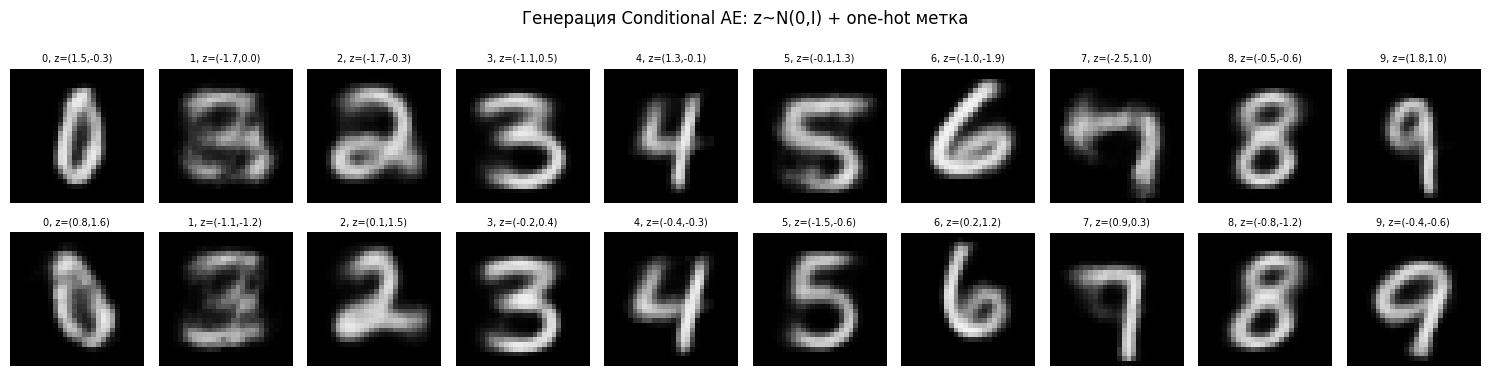

Задание 5 выполнено: случайный шум N(0,I) объединяется с one-hot условием внутри декодера.


In [54]:
generated_conditional, conditional_noise = demonstrate_conditional_generation(conditional_model, samples_per_class=2)
print('Задание 5 выполнено: случайный шум N(0,I) объединяется с one-hot условием внутри декодера.')


<p class="task" id="6"></p>

6\. Создайте и обучите модель вариационного автокодировщика, используя только полносвязные слои и функции активации.

Кодировщик - это функция следующего вида:
$$q_\phi(z|x) = \mathcal{N}(\mu_\phi(x), \sigma_\phi^2(x))$$

Здесь $\phi$ - параметры кодировщика, а $\mu_\phi(x)$ и $\sigma_\phi^2(x)$ - это обучаемые функции (в нашем случае - полносвязные слои).

Чтобы иметь возможность обучить такую модель, используется т.н. reparametrization trick: на основе функций $\mu$ и $ \sigma$ считаем значение:

$$z = \mu_\phi(x) + \sigma_\phi(x) \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

Декодировщик пытается восстановить исходное изображение из полученного вектора:

$$p_\theta(x|z) = f(z; \theta)$$

В качестве функции потерь обычно используется следующая:
$$\mathcal{L}_{total} = \mathcal{L}_{recon} + D_{KL}$$
$$\mathcal{L}_{recon} = -\sum_{i=1}^D [x_i \log \hat{x}_i + (1 - x_i) \log (1 - \hat{x}_i)]$$
$$D_{KL} = -\frac{1}{2} \sum_{j=1}^J (1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2)$$


- [ ] Проверено на семинаре

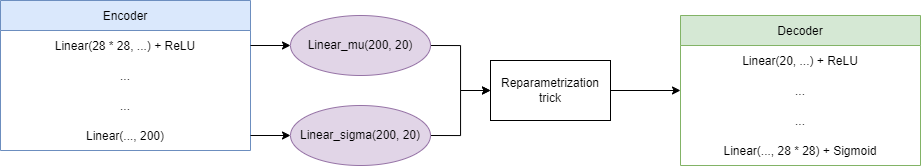

In [55]:
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


In [56]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=(512, 256), latent_dim=20):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        enc=[]; prev=input_dim
        for h in hidden_dims:
            enc += [nn.Linear(prev,h), nn.ReLU()]; prev=h
        self.encoder_hidden = nn.Sequential(*enc)
        self.fc_mu = nn.Linear(prev, latent_dim)
        self.fc_logvar = nn.Linear(prev, latent_dim)
        dec=[]; prev=latent_dim
        for h in reversed(hidden_dims):
            dec += [nn.Linear(prev,h), nn.ReLU()]; prev=h
        dec += [nn.Linear(prev,input_dim), nn.Sigmoid()]
        self.decoder = nn.Sequential(*dec)

    def encode(self, x):
        h=self.encoder_hidden(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std=torch.exp(0.5*logvar)
        return mu + std*torch.randn_like(std)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar=self.encode(x)
        z=self.reparameterize(mu,logvar)
        return self.decode(z), mu, logvar, z


In [57]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    # Формулы из условия: BCE-реконструкция + KL(q(z|x)||N(0,I))
    recon = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    batch = x.size(0)
    return (recon + beta*kl)/batch, recon/batch, kl/batch


In [58]:
model = VariationalAutoencoder(latent_dim=20).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [59]:
num_epochs = 20
train_losses=[]; train_recon_losses=[]; train_kld_losses=[]
for epoch in range(num_epochs):
    model.train(); totals=np.zeros(3, dtype=float)
    for data,_ in train_loader:
        data=data.view(data.size(0),-1).to(device)
        recon,mu,logvar,z=model(data)
        total,recon_loss,kl=vae_loss(recon,data,mu,logvar)
        optimizer.zero_grad(); total.backward(); optimizer.step()
        totals += [total.item(), recon_loss.item(), kl.item()]
    totals /= len(train_loader)
    train_losses.append(totals[0]); train_recon_losses.append(totals[1]); train_kld_losses.append(totals[2])
    print(f'Epoch [{epoch+1:02d}/{num_epochs}] total={totals[0]:.3f} recon={totals[1]:.3f} KL={totals[2]:.3f}')
torch.save(model.state_dict(), 'vae_model.pth')
print('Модель сохранена: vae_model.pth')


Epoch [01/20] total=175.485 recon=167.611 KL=7.874
Epoch [02/20] total=127.769 recon=113.452 KL=14.317
Epoch [03/20] total=117.429 recon=101.166 KL=16.263
Epoch [04/20] total=112.398 recon=94.965 KL=17.433
Epoch [05/20] total=109.458 recon=91.457 KL=18.002
Epoch [06/20] total=107.486 recon=89.150 KL=18.336
Epoch [07/20] total=106.089 recon=87.523 KL=18.566
Epoch [08/20] total=105.068 recon=86.367 KL=18.701
Epoch [09/20] total=104.250 recon=85.388 KL=18.862
Epoch [10/20] total=103.580 recon=84.613 KL=18.968
Epoch [11/20] total=102.927 recon=83.878 KL=19.049
Epoch [12/20] total=102.491 recon=83.355 KL=19.137
Epoch [13/20] total=102.065 recon=82.858 KL=19.207
Epoch [14/20] total=101.676 recon=82.427 KL=19.249
Epoch [15/20] total=101.308 recon=82.014 KL=19.294
Epoch [16/20] total=100.971 recon=81.641 KL=19.330
Epoch [17/20] total=100.696 recon=81.304 KL=19.392
Epoch [18/20] total=100.485 recon=81.028 KL=19.457
Epoch [19/20] total=100.238 recon=80.758 KL=19.480
Epoch [20/20] total=99.991 re

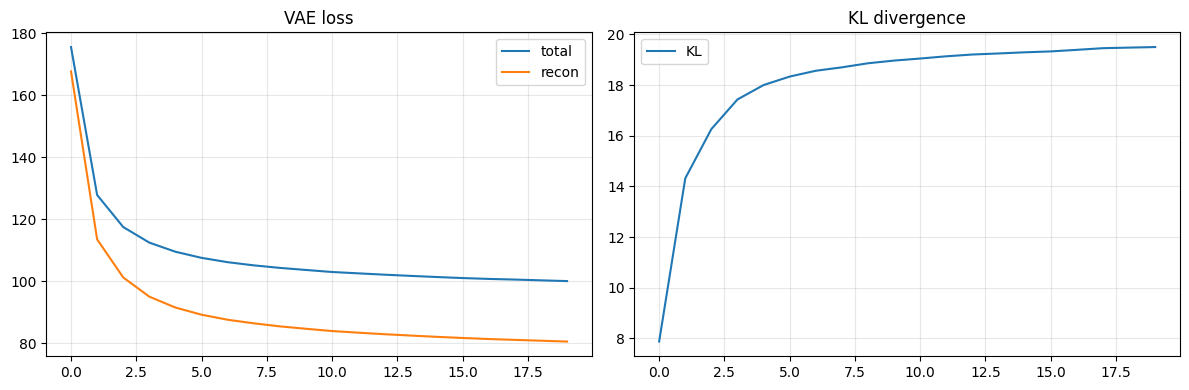

In [60]:
fig, axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(train_losses,label='total'); axes[0].plot(train_recon_losses,label='recon'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(train_kld_losses,label='KL'); axes[1].legend(); axes[1].grid(alpha=.3)
axes[0].set_title('VAE loss'); axes[1].set_title('KL divergence'); plt.tight_layout(); plt.show()


In [61]:
model.eval(); total=np.zeros(3,dtype=float)
with torch.no_grad():
    for data,_ in test_loader:
        data=data.view(data.size(0),-1).to(device)
        recon,mu,logvar,z=model(data)
        losses=vae_loss(recon,data,mu,logvar)
        total += [v.item() for v in losses]
total /= len(test_loader)
print(f'Test: total={total[0]:.3f}, recon={total[1]:.3f}, KL={total[2]:.3f}')


Test: total=100.640, recon=81.288, KL=19.352


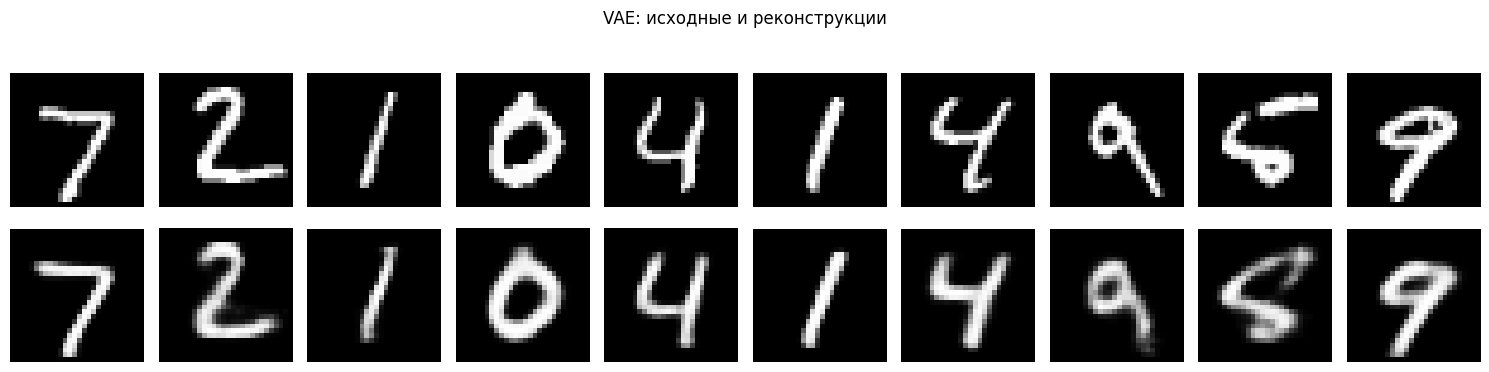

In [62]:
model.eval(); images,labels=next(iter(test_loader))
with torch.no_grad(): recon,mu,logvar,z=model(images.view(images.size(0),-1).to(device))
fig,axes=plt.subplots(2,10,figsize=(15,4))
for i in range(10):
    axes[0,i].imshow(images[i,0],cmap='gray'); axes[1,i].imshow(recon[i].cpu().view(28,28),cmap='gray')
    axes[0,i].axis('off'); axes[1,i].axis('off')
plt.suptitle('VAE: исходные и реконструкции'); plt.tight_layout(); plt.show()


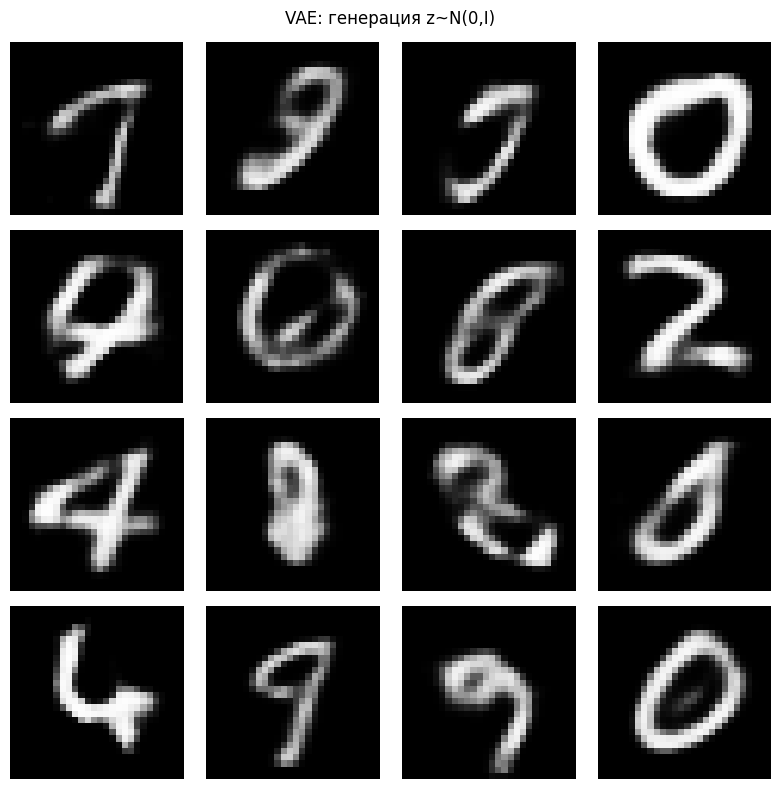

In [63]:
def generate_new_samples(model, num_samples=16):
    model.eval(); model_device=next(model.parameters()).device
    with torch.no_grad():
        z=torch.randn(num_samples, model.latent_dim, device=model_device)
        samples=model.decode(z).cpu()
    side=int(np.ceil(np.sqrt(num_samples)))
    fig,axes=plt.subplots(side,side,figsize=(8,8)); axes=np.asarray(axes).reshape(side,side)
    for i,ax in enumerate(axes.flat):
        if i<num_samples: ax.imshow(samples[i].view(28,28),cmap='gray',vmin=0,vmax=1)
        ax.axis('off')
    plt.suptitle('VAE: генерация z~N(0,I)'); plt.tight_layout(); plt.show()
    return samples,z.cpu()
vae_samples, vae_noise = generate_new_samples(model,16)


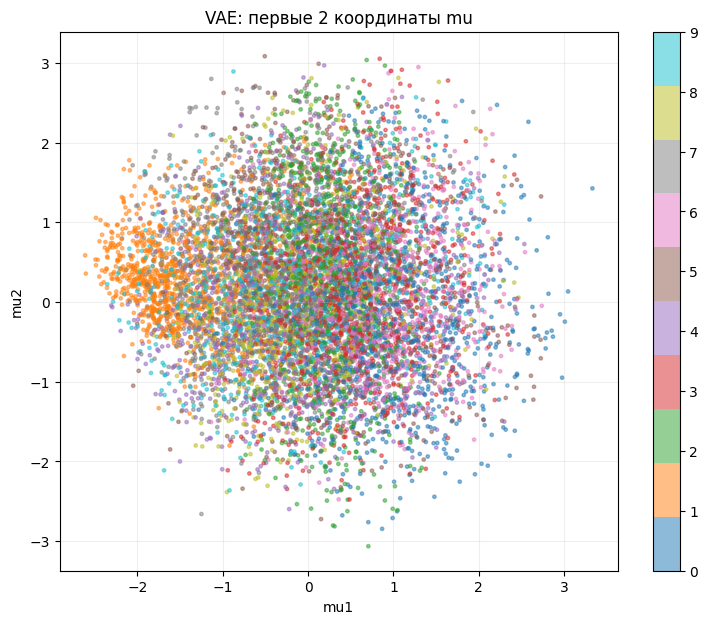

In [64]:
# Первые две координаты среднего mu для тестового набора
mus=[]; ys=[]; model.eval()
with torch.no_grad():
    for data,labels in test_loader:
        mu,_=model.encode(data.view(data.size(0),-1).to(device)); mus.append(mu.cpu().numpy()); ys.append(labels.numpy())
mus=np.concatenate(mus); ys=np.concatenate(ys)
plt.figure(figsize=(9,7)); sc=plt.scatter(mus[:,0],mus[:,1],c=ys,cmap='tab10',s=6,alpha=.5)
plt.colorbar(sc,ticks=range(10)); plt.xlabel('mu1'); plt.ylabel('mu2'); plt.title('VAE: первые 2 координаты mu'); plt.grid(alpha=.2); plt.show()


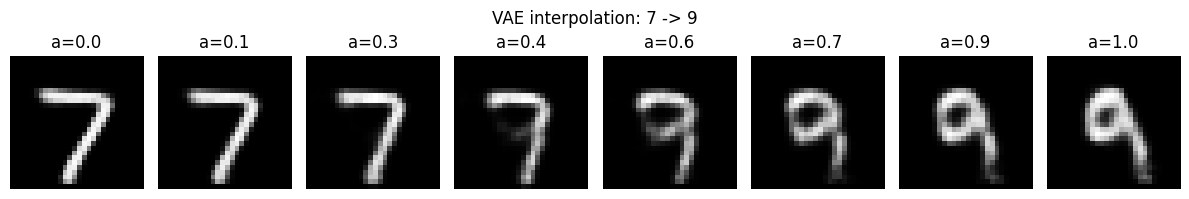

In [65]:
# Интерполяция между средними mu двух тестовых изображений
images,labels=next(iter(test_loader)); idx1,idx2=0,7
with torch.no_grad():
    mu1,_=model.encode(images[idx1:idx1+1].view(1,-1).to(device)); mu2,_=model.encode(images[idx2:idx2+1].view(1,-1).to(device))
    alphas=torch.linspace(0,1,8,device=device)
    imgs=[model.decode((1-a)*mu1+a*mu2).cpu() for a in alphas]
fig,axes=plt.subplots(1,8,figsize=(12,2))
for i,ax in enumerate(axes): ax.imshow(imgs[i].view(28,28),cmap='gray'); ax.axis('off'); ax.set_title(f'a={alphas[i].item():.1f}')
plt.suptitle(f'VAE interpolation: {labels[idx1].item()} -> {labels[idx2].item()}'); plt.tight_layout(); plt.show()


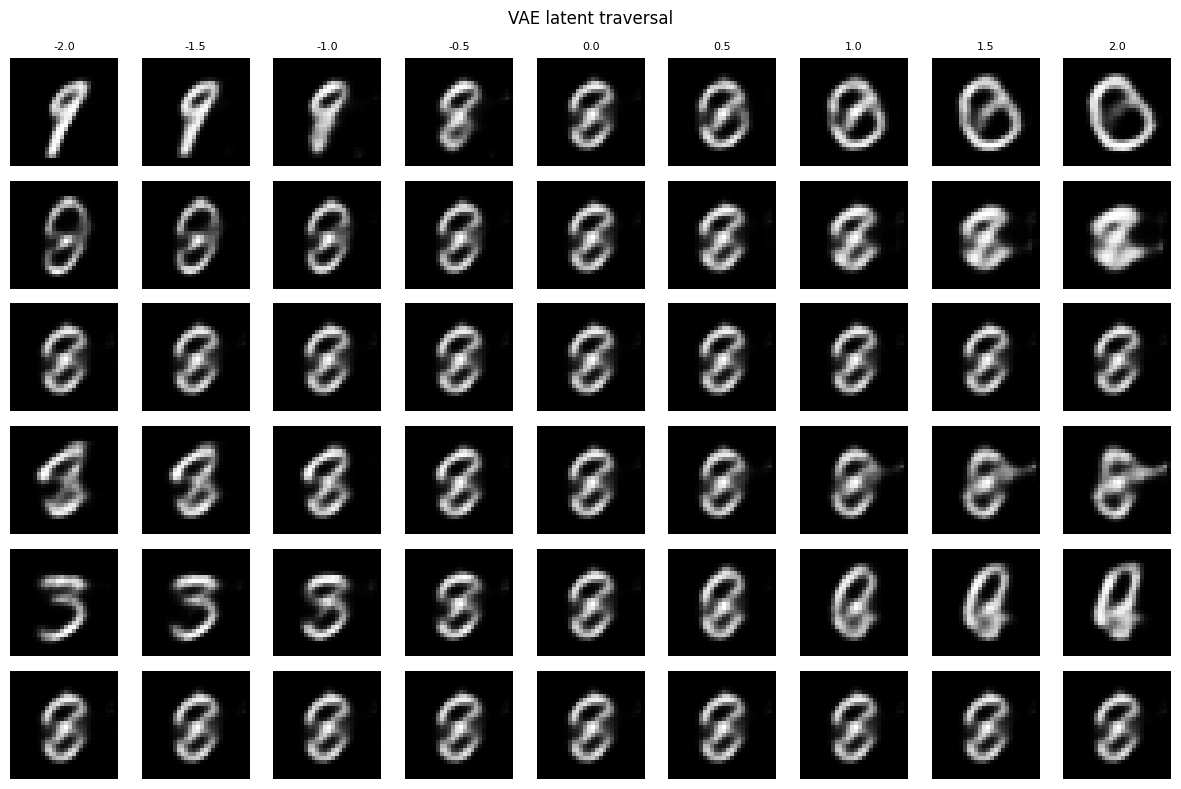

In [66]:
# Компактный latent traversal по первым 6 координатам
num_dims=min(6,model.latent_dim); values=torch.linspace(-2,2,9,device=device); base=torch.zeros(1,model.latent_dim,device=device)
fig,axes=plt.subplots(num_dims,len(values),figsize=(12,8))
with torch.no_grad():
    for d in range(num_dims):
        for j,val in enumerate(values):
            z=base.clone(); z[0,d]=val; img=model.decode(z).cpu().view(28,28)
            axes[d,j].imshow(img,cmap='gray'); axes[d,j].axis('off')
            if d==0: axes[d,j].set_title(f'{val.item():.1f}',fontsize=8)
            if j==0: axes[d,j].set_ylabel(f'z{d}',rotation=0)
plt.suptitle('VAE latent traversal'); plt.tight_layout(); plt.show()


<p class="task" id="7"></p>

7\. Напишите функцию для генерации изображения на основе случайного шума. Функция должна генерировать случайный шум из стандартного нормального распределения. Далее вектор пропускается его через часть-декодировщик. Сгенерируйте несколько изображений и визуализируйте в виде сетки из картинок.

- [ ] Проверено на семинаре

In [67]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=(512, 256), latent_dim=20):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        enc=[]; prev=input_dim
        for h in hidden_dims:
            enc += [nn.Linear(prev,h), nn.ReLU()]; prev=h
        self.encoder_hidden = nn.Sequential(*enc)
        self.fc_mu = nn.Linear(prev, latent_dim)
        self.fc_logvar = nn.Linear(prev, latent_dim)
        dec=[]; prev=latent_dim
        for h in reversed(hidden_dims):
            dec += [nn.Linear(prev,h), nn.ReLU()]; prev=h
        dec += [nn.Linear(prev,input_dim), nn.Sigmoid()]
        self.decoder = nn.Sequential(*dec)

    def encode(self, x):
        h=self.encoder_hidden(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std=torch.exp(0.5*logvar)
        return mu + std*torch.randn_like(std)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar=self.encode(x)
        z=self.reparameterize(mu,logvar)
        return self.decode(z), mu, logvar, z


In [68]:
def generate_images_from_noise(model, num_images=16):
    """Генерирует z~N(0,I) и пропускает z через декодер VAE."""
    model.eval(); model_device=next(model.parameters()).device
    with torch.no_grad():
        noise=torch.randn(num_images,model.latent_dim,device=model_device)
        generated=model.decode(noise)
    return generated.cpu(), noise.cpu()


In [69]:
def visualize_generated_grid(generated_images, noise_vectors=None, nrows=4, ncols=4, title='VAE: случайная генерация'):
    fig,axes=plt.subplots(nrows,ncols,figsize=(9,9)); axes=np.asarray(axes).reshape(nrows,ncols)
    for i,ax in enumerate(axes.flat):
        if i<len(generated_images):
            ax.imshow(generated_images[i].view(28,28),cmap='gray',vmin=0,vmax=1)
            if noise_vectors is not None: ax.set_title(f'z1={noise_vectors[i,0]:.2f}, z2={noise_vectors[i,1]:.2f}',fontsize=7)
        ax.axis('off')
    plt.suptitle(title); plt.tight_layout(); plt.show()


In [70]:
def load_vae(path='vae_model.pth'):
    m=VariationalAutoencoder(latent_dim=20).to(device)
    m.load_state_dict(load_state_dict_safe(path,map_location=device))
    m.eval(); return m
vae_for_generation=load_vae()


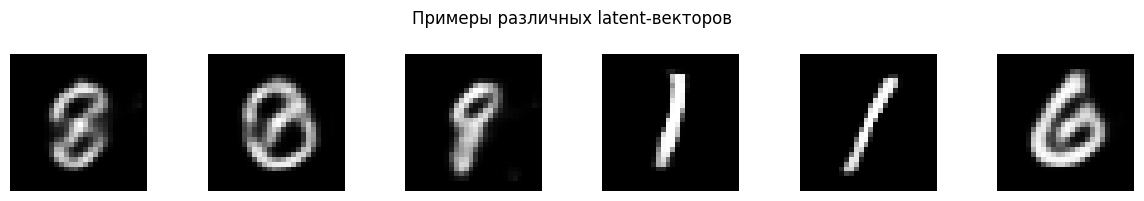

In [71]:
with torch.no_grad():
    z_examples=torch.stack([
        torch.zeros(20),
        torch.cat([torch.tensor([1.0]),torch.zeros(19)]),
        torch.cat([torch.tensor([-1.0]),torch.zeros(19)]),
        torch.randn(20),
        2*torch.randn(20),
        torch.full((20,),0.5),
    ]).to(device)
    imgs_examples=vae_for_generation.decode(z_examples).cpu()
fig,axes=plt.subplots(1,6,figsize=(12,2))
for i,ax in enumerate(axes): ax.imshow(imgs_examples[i].view(28,28),cmap='gray'); ax.axis('off')
plt.suptitle('Примеры различных latent-векторов'); plt.tight_layout(); plt.show()


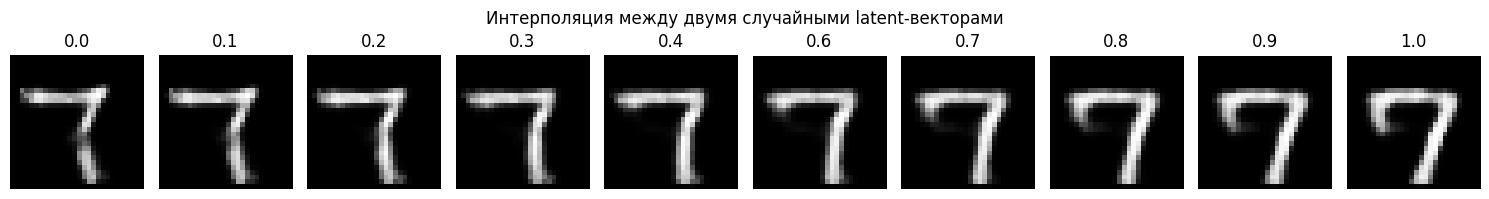

In [72]:
# Интерполяция между двумя случайными z~N(0,I)
z_a=torch.randn(1,20,device=device); z_b=torch.randn(1,20,device=device); alphas=torch.linspace(0,1,10,device=device)
with torch.no_grad(): imgs_interp=[vae_for_generation.decode((1-a)*z_a+a*z_b).cpu() for a in alphas]
fig,axes=plt.subplots(1,10,figsize=(15,2))
for i,ax in enumerate(axes): ax.imshow(imgs_interp[i].view(28,28),cmap='gray'); ax.axis('off'); ax.set_title(f'{alphas[i].item():.1f}')
plt.suptitle('Интерполяция между двумя случайными latent-векторами'); plt.tight_layout(); plt.show()


In [73]:
def run_task7_demo(num_images=16):
    generated, noise = generate_images_from_noise(vae_for_generation, num_images=num_images)
    side=int(np.ceil(np.sqrt(num_images)))
    visualize_generated_grid(generated, noise, side, side, 'Задание 7: z~N(0,I) -> VAE decoder')
    return generated, noise


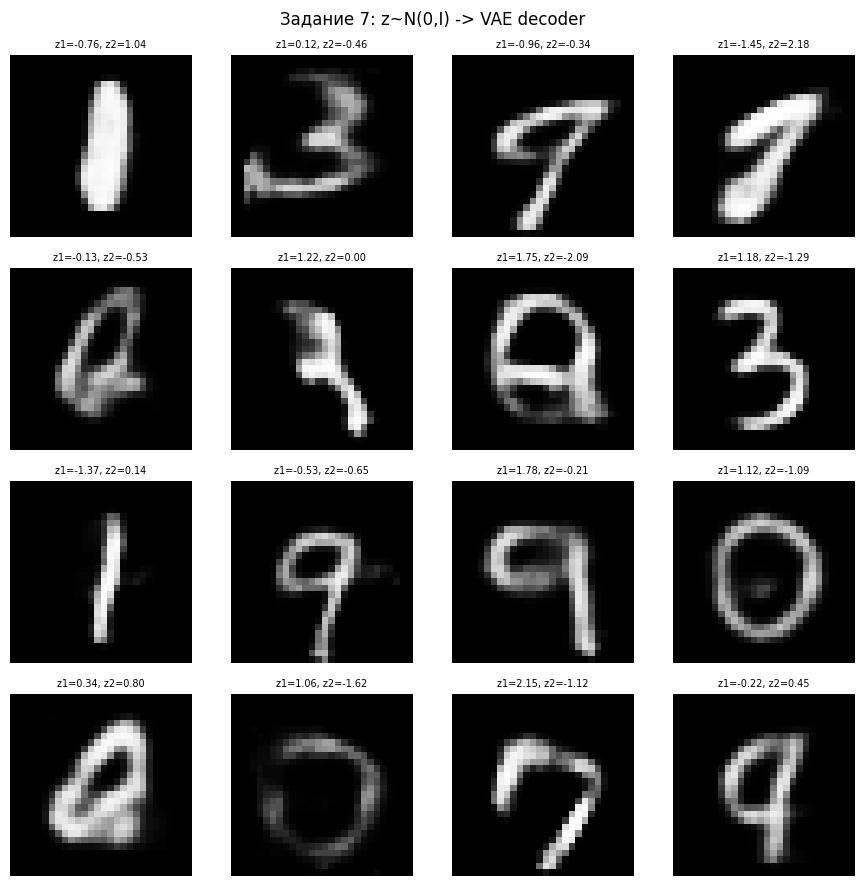

Задание 7 выполнено: изображения сгенерированы из стандартного нормального шума.


In [74]:
generated_vae_images, generated_vae_noise = run_task7_demo(16)
print('Задание 7 выполнено: изображения сгенерированы из стандартного нормального шума.')


## Обратная связь
- [ ] Почта: d83073452@yandex.ru
- [ ] Gmail: 3073452@gmail.com
- [ ] Telegram: @sleepingzzzZ